---
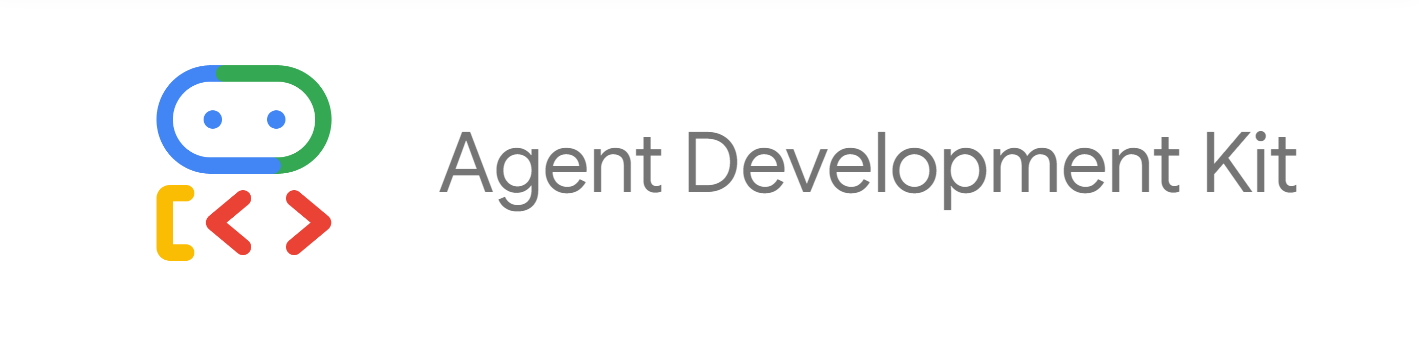

---
# Session, State And Memory in ADK

---

## Session: Tracking Individual Conversations
Following our Introduction, let's dive into the `Session`. Think back to the idea of a "conversation thread." Just like you wouldn't start every text message from scratch, agents need context regarding the ongoing interaction. `Session` is the ADK object designed specifically to track and manage these individual conversation threads.

## The **Session** Object
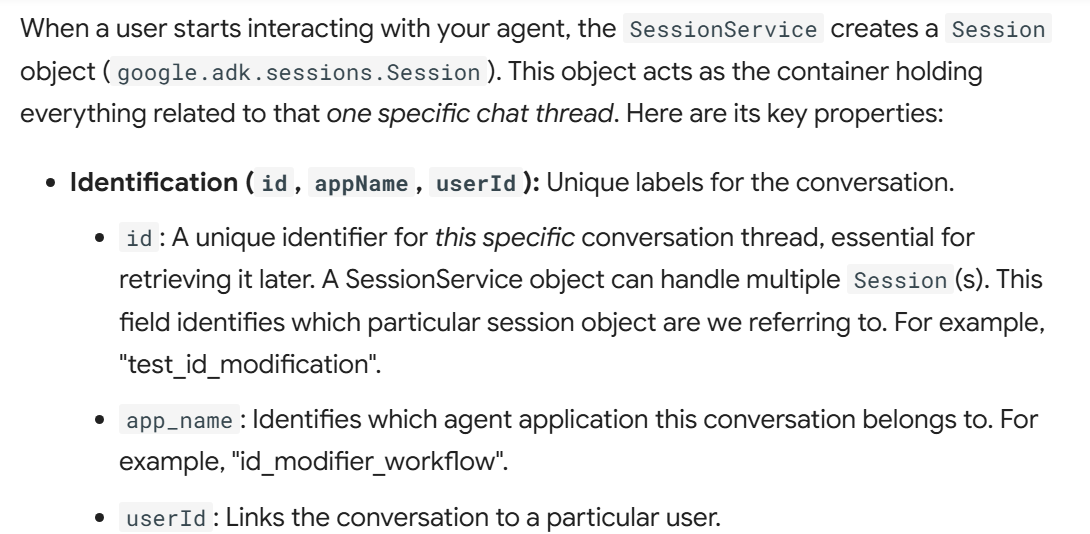 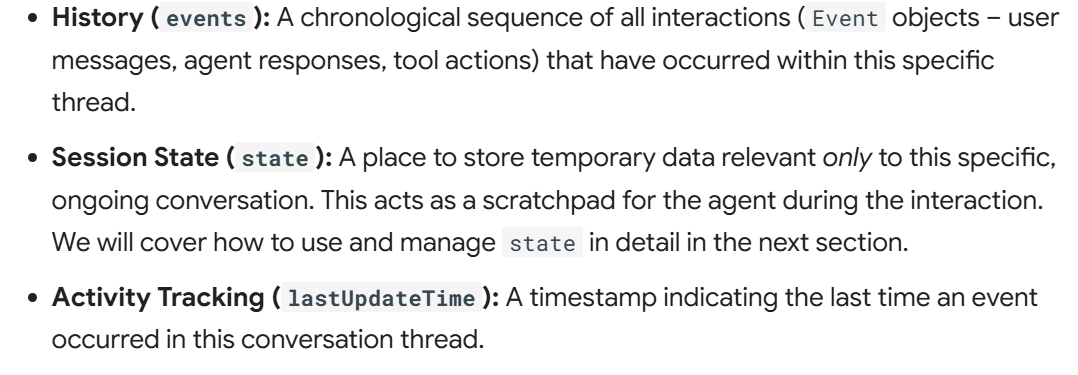 <br><br>

### `Example: Examining Session Properties`
```Python
 from google.adk.sessions import InMemorySessionService, Session

 # Create a simple session to examine its properties
 temp_service = InMemorySessionService()
 example_session = await temp_service.create_session(
     app_name="my_app",
     user_id="example_user",
     state={"initial_key": "initial_value"} # State can be initialized
 )

 print(f"--- Examining Session Properties ---")
 print(f"ID (`id`):                {example_session.id}")
 print(f"Application Name (`app_name`): {example_session.app_name}")
 print(f"User ID (`user_id`):         {example_session.user_id}")
 print(f"State (`state`):           {example_session.state}") # Note: Only shows initial state here
 print(f"Events (`events`):         {example_session.events}") # Initially empty
 print(f"Last Update (`last_update_time`): {example_session.last_update_time:.2f}")
 print(f"---------------------------------")

 # Clean up (optional for this example)
 temp_service = await temp_service.delete_session(app_name=example_session.app_name,
                             user_id=example_session.user_id, session_id=example_session.id)
 print("The final status of temp_service - ", temp_service)
```

> (Note: The state shown above is only the initial state. State updates happen via events, as discussed in the State section.)

---

## Managing Sessions with a **SessionService**
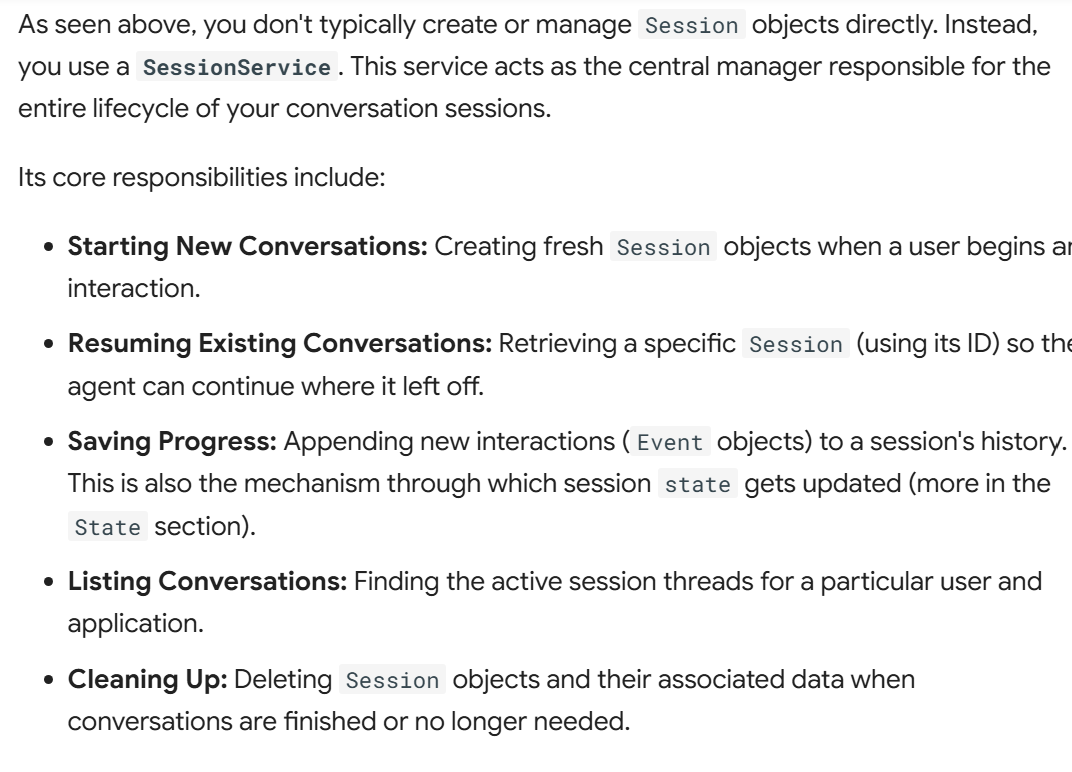 <br><br> 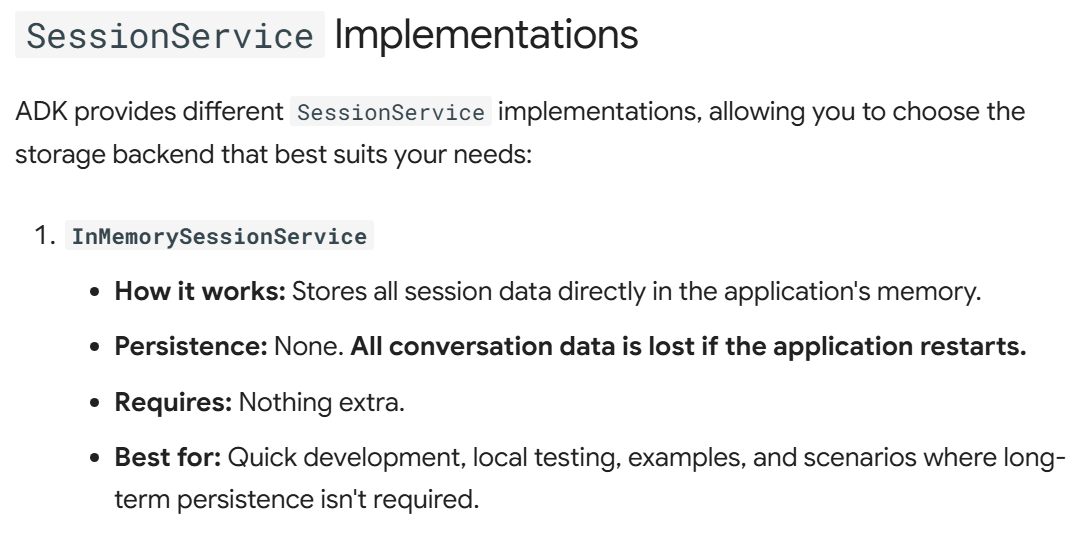 <br>

```Python
 from google.adk.sessions import InMemorySessionService
 session_service = InMemorySessionService()
```

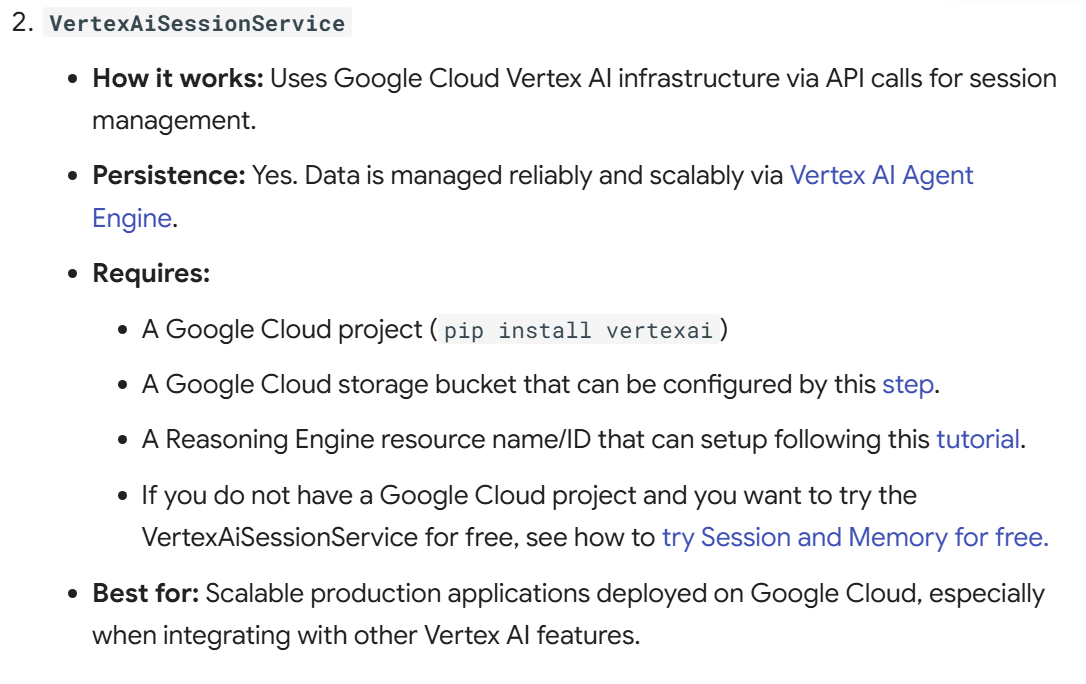 

```Python
# Requires: pip install google-adk[vertexai]
# Plus GCP setup and authentication
from google.adk.sessions import VertexAiSessionService

PROJECT_ID = "your-gcp-project-id"
LOCATION = "us-central1"
# The app_name used with this service should be the Reasoning Engine ID or name
REASONING_ENGINE_APP_NAME = "projects/your-gcp-project-id/locations/us-central1/reasoningEngines/your-engine-id"

session_service = VertexAiSessionService(project=PROJECT_ID, location=LOCATION)
# Use REASONING_ENGINE_APP_NAME when calling service methods, e.g.:
# session_service = await session_service.create_session(app_name=REASONING_ENGINE_APP_NAME, ...)
```

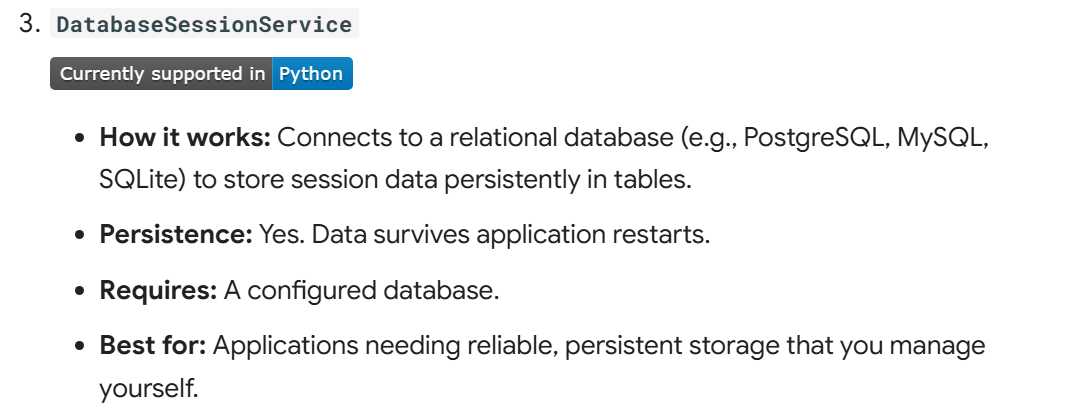

```Python
from google.adk.sessions import DatabaseSessionService
# Example using a local SQLite file:
db_url = "sqlite:///./my_agent_data.db"
session_service = DatabaseSessionService(db_url=db_url)
```

## Choosing the right `SessionService` is key to defining how your agent's conversation history and temporary data are stored and persist.

## The Session Lifecycle¶

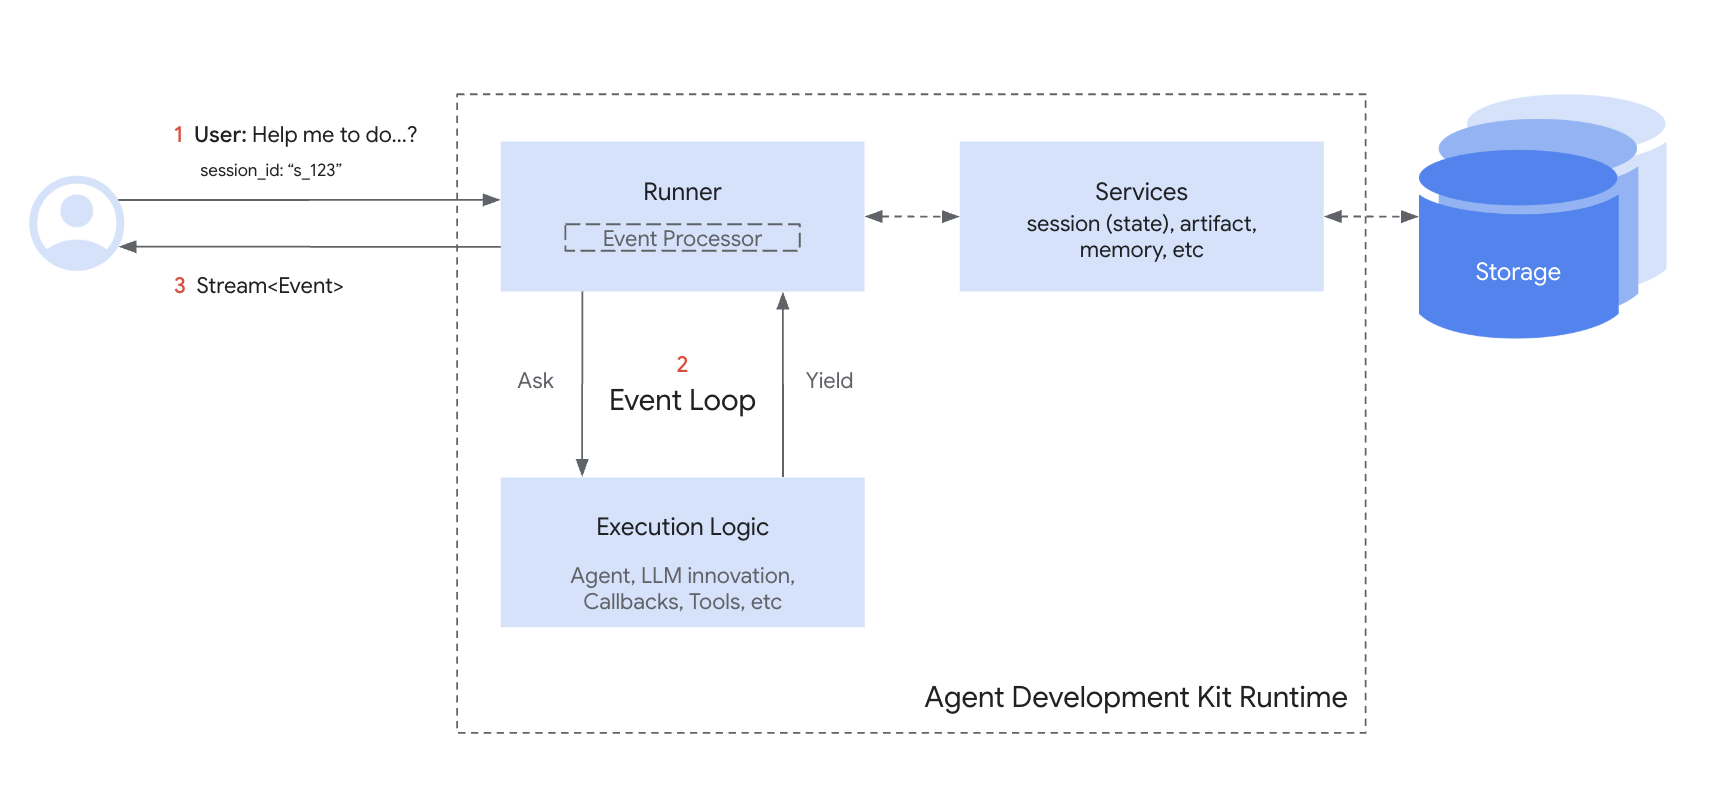

Here’s a simplified flow of how Session and SessionService work together during a conversation turn:

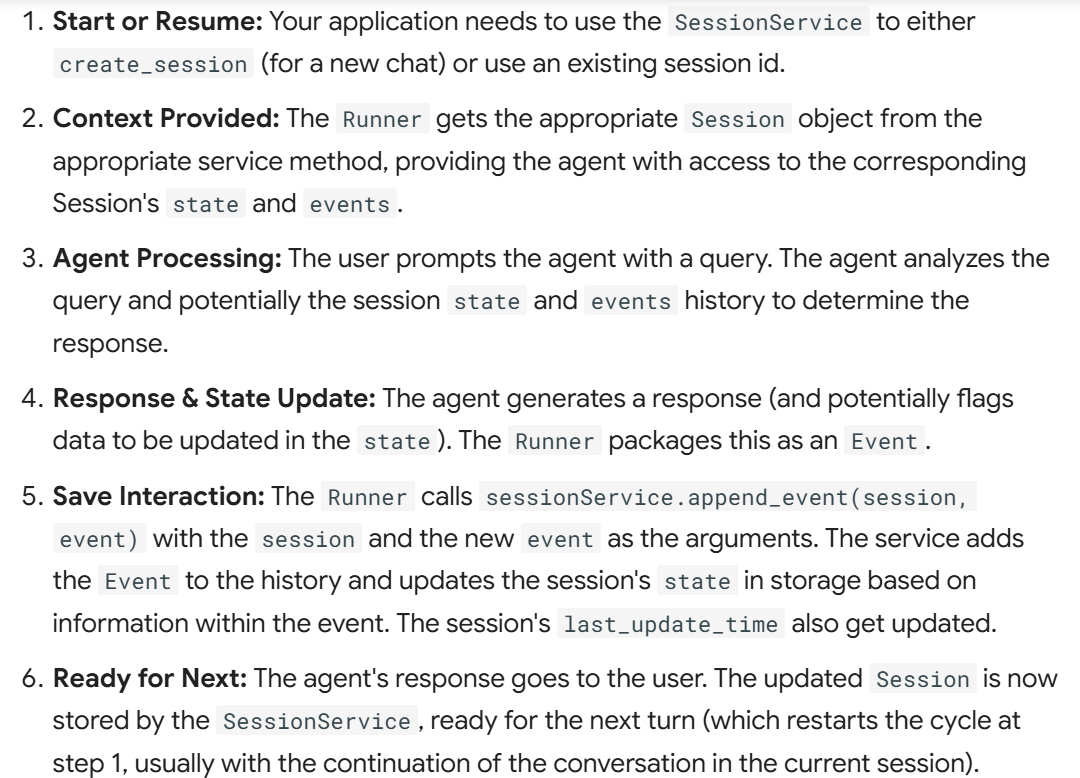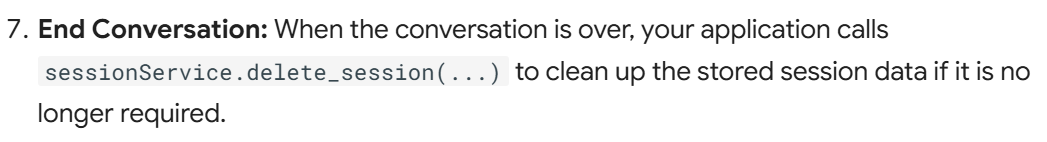

> This cycle highlights how the `SessionService` ensures conversational continuity by managing the history and state associated with each `Session` object.


---